In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import dlib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [17]:
def extract_landmark_points(shape, start, end):
  points = []
  for i in range(start, end):
    point = shape.part(i)
    # Landmark coordinates
    x = point.x
    y = point.y
    points.append((x, y))
  points = np.array(points, dtype=np.int32)
  return points

In [19]:
def draw_landmark(frame, points, color= (0, 255, 0)):
  cv.polylines(
      frame,
      [points],
      True,
      color,
      3
  )

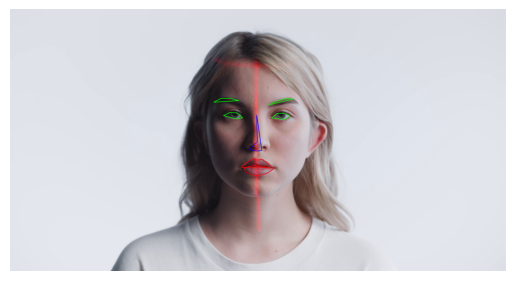

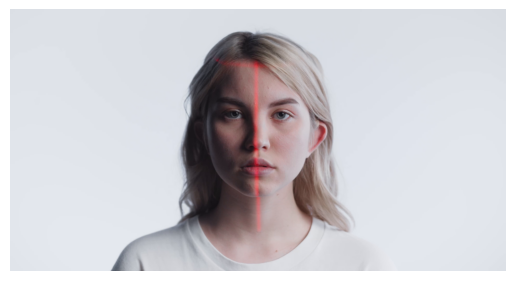

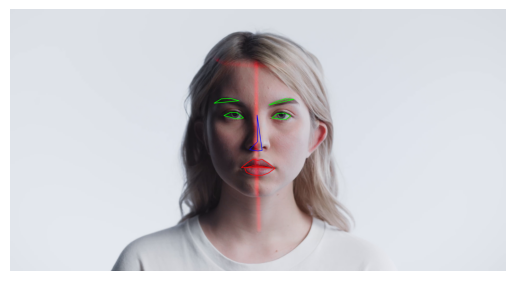

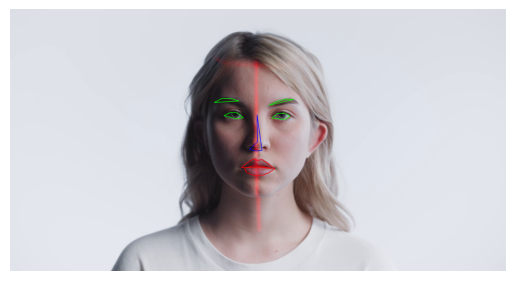

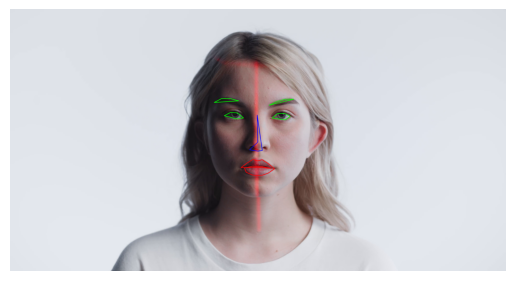

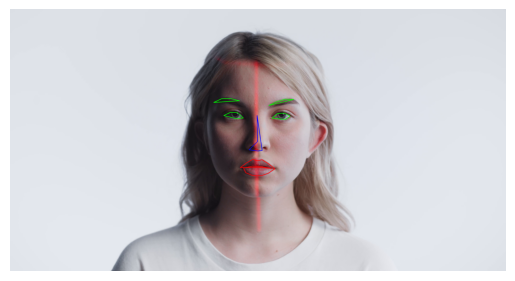

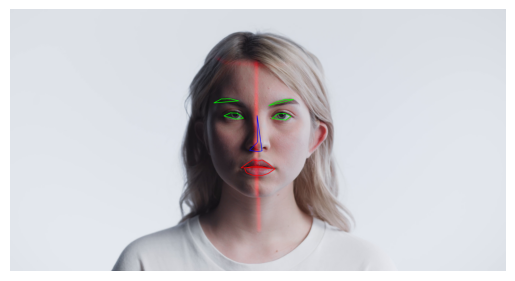

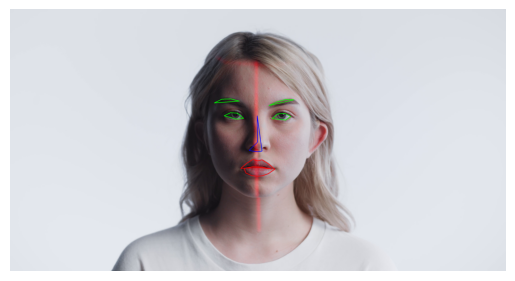

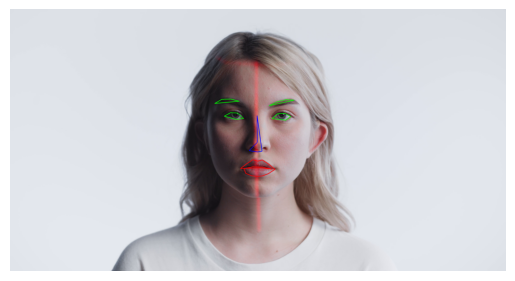

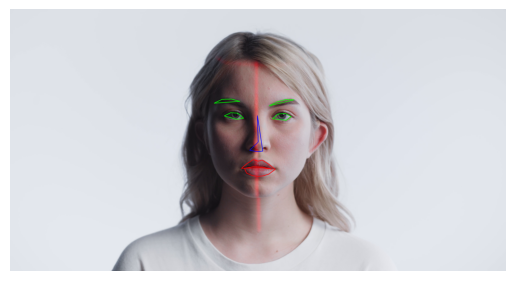

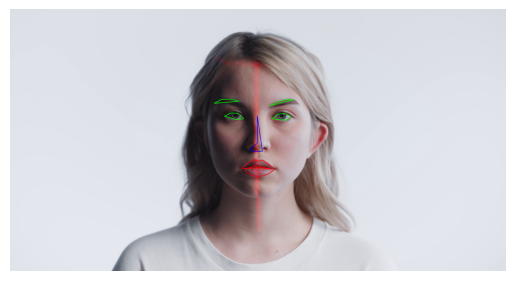

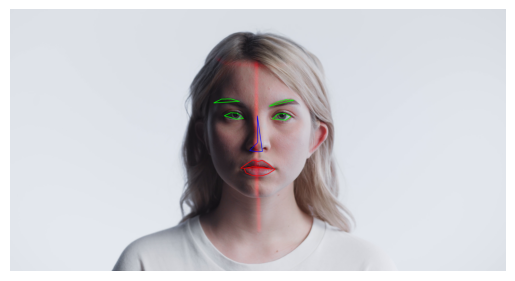

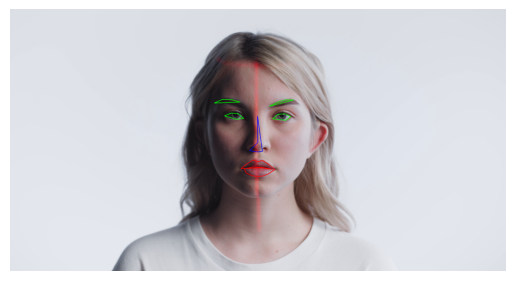

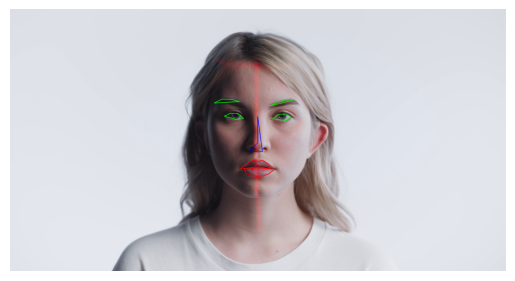

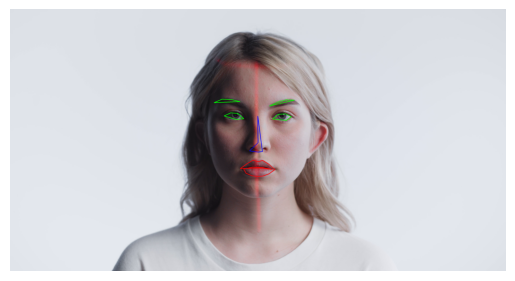

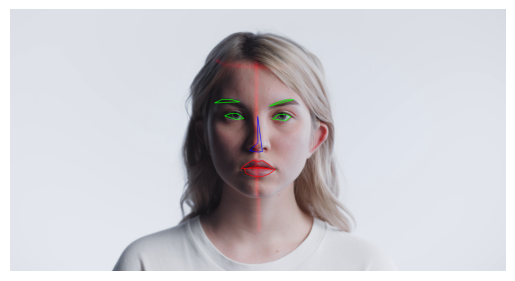

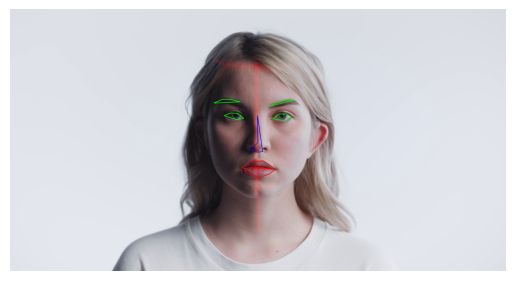

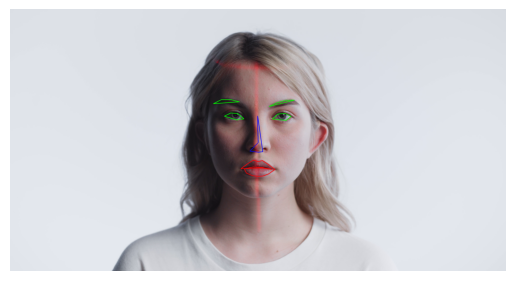

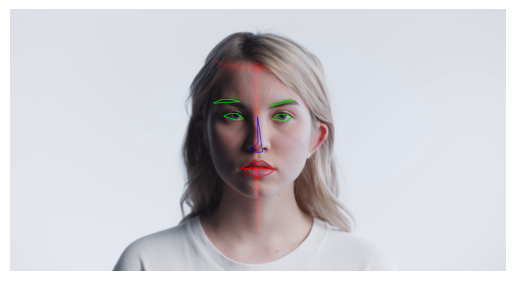

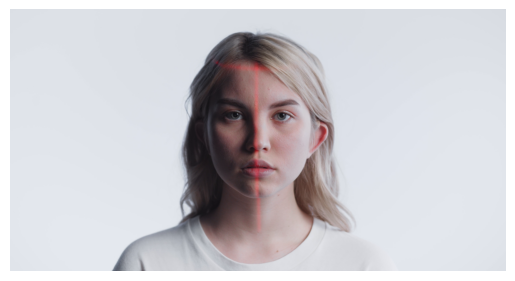

In [23]:

# Load Dlib face detector
detector = dlib.get_frontal_face_detector()


# Load pretrained 68 facial landmark model
# ----------------------------------------------------
predictor = dlib.shape_predictor(
    "/content/drive/MyDrive/Colab Notebooks/videos/shape_predictor_68_face_landmarks.dat"
)


# Open video (or replace 0 with webcam)
cap = cv.VideoCapture("/content/drive/MyDrive/Colab Notebooks/videos/face.mp4")

for i in range(20):

    # Read next frame
    ret, frame = cap.read()

    if not ret:
        break

    # Convert frame to grayscale
    gray = cv.cvtColor(
        frame,
        cv.COLOR_BGR2GRAY
    )

    # Detect all faces in current frame
    faces = detector(gray)

    # Process every detected face
    for face in faces:

        # Predict 68 facial landmarks
        shape = predictor(gray, face)
        # Draw every landmark
        FACIAL_LANDMARKS = {
        "left_eyebrow": (17, 21, (0, 255, 0)),
        "right_eyebrow": (22, 26, (0, 255, 0)),
        "nose": (27, 35, (255, 0, 0)),
        "left_eye": (36, 41, (0, 255, 0)),
        "right_eye": (42, 47, (0, 255, 0)),
        "mouth": (48, 67, (0, 0, 255)),
          }
        for name, (start, end, color) in FACIAL_LANDMARKS.items():
          points = extract_landmark_points(shape, start, end)
          draw_landmark(frame, points, color= color)

    # Show result
    imshow(frame)



# Release resources
cap.release()